### imports

In [1]:
import pandas as pd 
import numpy as np

### Download and load dataset

In [2]:
import os
os.environ["HF_HOME"] = "F:\Programming\Transfomers\data"

In [3]:
from datasets import load_dataset
ds = load_dataset("priyank-m/SROIE_2019_text_recognition")

### data visualization

In [4]:
sample = ds["train"][0]

print(sample.keys())   # see structure
print(sample)

dict_keys(['image', 'text'])
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=254x39 at 0x2518A538050>, 'text': 'TAN WOON YANN'}


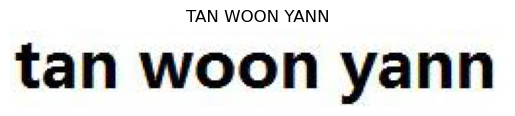

In [5]:
import matplotlib.pyplot as plt

sample = ds["train"][0]

image = sample["image"]
text = sample["text"]

plt.imshow(image)
plt.title(text)
plt.axis("off")
plt.show()

In [6]:
text

'TAN WOON YANN'

In [7]:
text[0]

'T'

### data transformation

In [8]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((64, 256)),   # fixed OCR size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

### Character Vocabulary

In [9]:
import string

chars = string.ascii_letters + string.digits + string.punctuation + " "
char2idx = {c: i+1 for i, c in enumerate(chars)}  # 0 reserved for padding
char2idx["<pad>"] = 0
char2idx["<eos>"] = len(char2idx)
char2idx["<bos>"] = len(char2idx) + 1
idx2char = {i: c for c, i in char2idx.items()}

vocab_size = len(char2idx) + 1
print("Vocab size:", vocab_size)

Vocab size: 99


In [10]:
char2idx

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 'A': 27,
 'B': 28,
 'C': 29,
 'D': 30,
 'E': 31,
 'F': 32,
 'G': 33,
 'H': 34,
 'I': 35,
 'J': 36,
 'K': 37,
 'L': 38,
 'M': 39,
 'N': 40,
 'O': 41,
 'P': 42,
 'Q': 43,
 'R': 44,
 'S': 45,
 'T': 46,
 'U': 47,
 'V': 48,
 'W': 49,
 'X': 50,
 'Y': 51,
 'Z': 52,
 '0': 53,
 '1': 54,
 '2': 55,
 '3': 56,
 '4': 57,
 '5': 58,
 '6': 59,
 '7': 60,
 '8': 61,
 '9': 62,
 '!': 63,
 '"': 64,
 '#': 65,
 '$': 66,
 '%': 67,
 '&': 68,
 "'": 69,
 '(': 70,
 ')': 71,
 '*': 72,
 '+': 73,
 ',': 74,
 '-': 75,
 '.': 76,
 '/': 77,
 ':': 78,
 ';': 79,
 '<': 80,
 '=': 81,
 '>': 82,
 '?': 83,
 '@': 84,
 '[': 85,
 '\\': 86,
 ']': 87,
 '^': 88,
 '_': 89,
 '`': 90,
 '{': 91,
 '|': 92,
 '}': 93,
 '~': 94,
 ' ': 95,
 '<pad>': 0,
 '<eos>': 96,
 '<bos>': 98}

In [11]:
idx2char

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 27: 'A',
 28: 'B',
 29: 'C',
 30: 'D',
 31: 'E',
 32: 'F',
 33: 'G',
 34: 'H',
 35: 'I',
 36: 'J',
 37: 'K',
 38: 'L',
 39: 'M',
 40: 'N',
 41: 'O',
 42: 'P',
 43: 'Q',
 44: 'R',
 45: 'S',
 46: 'T',
 47: 'U',
 48: 'V',
 49: 'W',
 50: 'X',
 51: 'Y',
 52: 'Z',
 53: '0',
 54: '1',
 55: '2',
 56: '3',
 57: '4',
 58: '5',
 59: '6',
 60: '7',
 61: '8',
 62: '9',
 63: '!',
 64: '"',
 65: '#',
 66: '$',
 67: '%',
 68: '&',
 69: "'",
 70: '(',
 71: ')',
 72: '*',
 73: '+',
 74: ',',
 75: '-',
 76: '.',
 77: '/',
 78: ':',
 79: ';',
 80: '<',
 81: '=',
 82: '>',
 83: '?',
 84: '@',
 85: '[',
 86: '\\',
 87: ']',
 88: '^',
 89: '_',
 90: '`',
 91: '{',
 92: '|',
 93: '}',
 94: '~',
 95: ' ',
 0: '<pad>',
 96: '<eos>',
 98: '<bos>'}

### Text Encoding Function

In [12]:
max_len = max(map(len, ds["train"]["text"]))
print("Max length:", max_len)

Max length: 68


In [13]:
def encode_text(text, max_len=128):
    text = text[:max_len-2]  # reserve space for <bos> and <eos>
    
    tokens = [char2idx["<bos>"]] + [char2idx.get(c, 0) for c in text]
    tokens.append(char2idx["<eos>"])
    
    if len(tokens) < max_len:
        tokens += [0] * (max_len - len(tokens))
    
    return tokens

In [14]:
x= 'i am unknown'
x

'i am unknown'

In [15]:
x[:128-1]

'i am unknown'

In [16]:
x[1:]

' am unknown'

In [17]:
x = encode_text('i am unknown')
print(x)
print(len(x))

[98, 9, 95, 1, 13, 95, 21, 14, 11, 14, 15, 23, 14, 96, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
128


In [18]:
print(x[:128-1])
print(len(x[:128-1]))

[98, 9, 95, 1, 13, 95, 21, 14, 11, 14, 15, 23, 14, 96, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
127


In [19]:
print(x[1:])
print(len(x[1:]))

[9, 95, 1, 13, 95, 21, 14, 11, 14, 15, 23, 14, 96, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
127


### PyTorch Dataset Class

In [20]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [21]:
class OCRDataset(Dataset):
    def __init__(self, hf_dataset, transform=None, max_len=128):
        self.data = hf_dataset
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        image = sample["image"]
        text = sample["text"]

        if self.transform:
            image = self.transform(image)

        tokens = encode_text(text, self.max_len)

        return {
            "image": image,                      # (3, 64, 256)
            "input_ids": torch.tensor(tokens[:-1]),  # input
            "labels": torch.tensor(tokens[1:])       # target
        }

### Create Dataset + Check

In [22]:
train_dataset = OCRDataset(ds["train"], transform=transform)

sample = train_dataset[0]

print("Image shape:", sample["image"].shape)
print("Input IDs shape:", sample["input_ids"].shape)
print("Labels shape:", sample["labels"].shape)

Image shape: torch.Size([3, 64, 256])
Input IDs shape: torch.Size([127])
Labels shape: torch.Size([127])


In [23]:
test_dataset = OCRDataset(ds["test"], transform=transform)

sample = train_dataset[0]

print("Image shape:", sample["image"].shape)
print("Input IDs shape:", sample["input_ids"].shape)
print("Labels shape:", sample["labels"].shape)

Image shape: torch.Size([3, 64, 256])
Input IDs shape: torch.Size([127])
Labels shape: torch.Size([127])


### decode text function 

In [24]:
def decode(tokens):
    return "".join([idx2char.get(int(t), "") for t in tokens if t != 0])

In [25]:
print(decode(sample["input_ids"]))

<bos>TAN WOON YANN<eos>


### DataLoader

In [26]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

batch = next(iter(train_loader))

print(batch["image"].shape)      # (B, 3, 64, 256)
print(batch["input_ids"].shape)  # (B, T)
print(batch["labels"].shape)     # (B, T)

torch.Size([8, 3, 64, 256])
torch.Size([8, 127])
torch.Size([8, 127])


In [27]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

batch = next(iter(test_loader))

print(batch["image"].shape)      # (B, 3, 64, 256)
print(batch["input_ids"].shape)  # (B, T)
print(batch["labels"].shape)     # (B, T)

torch.Size([8, 3, 64, 256])
torch.Size([8, 127])
torch.Size([8, 127])


# Transfomer Architecture

Image:
→ PatchEmbed → Pos → ViT → image_tokens (B, 64, 768)

Text:
→ Embedding → Pos → text_tokens (B, 127, 768)

Decoder:
→ Masked Self-Attn (text)
→ Cross-Attn (text ↔ image)
→ FF

Output:
→ Linear → vocab

In [28]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import math

### Patch Embedding Module

In [29]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, d_model=768):
        super().__init__()
        
        self.proj = nn.Sequential(
            # (B, 3, 64, 256)
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=2, padding=1),   # → (B, 64, 32, 128)
            nn.GELU(),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),           # → (B, 128, 16, 64)
            nn.GELU(),
            
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),          # → (B, 256, 8, 32)
            nn.GELU(),
            
            nn.Conv2d(256, d_model, kernel_size=3, stride=2, padding=1),      # → (B, 768, 4, 16)
        )

    def forward(self, x):
        """
        x: (B, 3, 64, 256)
        """
        x = self.proj(x)                     # (B, 768, 4, 16)
        
        B, C, H, W = x.shape
        x = x.flatten(2)                    # (B, 768, 64)
        x = x.transpose(1, 2)               # (B, 64, 768)
        
        return x

In [30]:
x = torch.randn(2, 3, 64, 256)

patch_embed = PatchEmbedding()

out = patch_embed(x)

print("Output shape:", out.shape)

Output shape: torch.Size([2, 64, 768])


### ImagePositionalEmbedding

In [31]:
class ImagePositionalEmbedding(nn.Module):
    def __init__(self, num_patches=64, d_model=768):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, d_model))

    def forward(self, x):
        """
        x: (B, 64, 768)
        """
        return x + self.pos_embed

In [32]:
x = torch.randn(2, 64, 768)

pos = ImagePositionalEmbedding()

out = pos(x)

print(out.shape)

torch.Size([2, 64, 768])


### TextEmbedding + PositionalEmbedding

In [33]:
class TextPositionalEmbedding(nn.Module):
    def __init__(self, vocab_size, embdim, max_len=512):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embdim, padding_idx=0)

        pe = torch.zeros(max_len, embdim)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, embdim, 2) * (-math.log(10000.0) / embdim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))  # (1, T, D)

    def forward(self, x):
        B, T = x.size()
        emb = self.embedding(x)                      # (B, T, D)
        emb = emb + self.pe[:, :T, :]                # (B, T, D)
        return emb

In [34]:
x = torch.randint(1, 50, (2, 10))
model = TextPositionalEmbedding(vocab_size=100, embdim=768, max_len=512)
out = model(x)
print(x)
print("Input shape:", x.shape)      # (2, 10)
print("Output shape:", out.shape)   # (2, 10, 768)

tensor([[47,  6, 43, 40, 36, 10, 17, 35, 26, 43],
        [11, 31, 13, 26, 16, 39, 12, 20, 16, 25]])
Input shape: torch.Size([2, 10])
Output shape: torch.Size([2, 10, 768])


In [35]:
import matplotlib.pyplot as plt

In [36]:
def plot_pos(max_len = 300 ,embdim = 60,cmap='Spectral'):

    # build PE from formula
    pe = torch.zeros(max_len, embdim)
    position = torch.arange(0, max_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, embdim, 2) * (-math.log(10000.0) / embdim)
    )
    
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    
    # plot
    plt.figure(figsize=(18, 8))
    plt.imshow(pe.T, aspect="auto", cmap=cmap)
    plt.colorbar(label="PE value")
    plt.xlabel("Position")
    plt.ylabel("Embedding dimension")
    plt.title("Sinusoidal Positional Encoding ")
    plt.show()


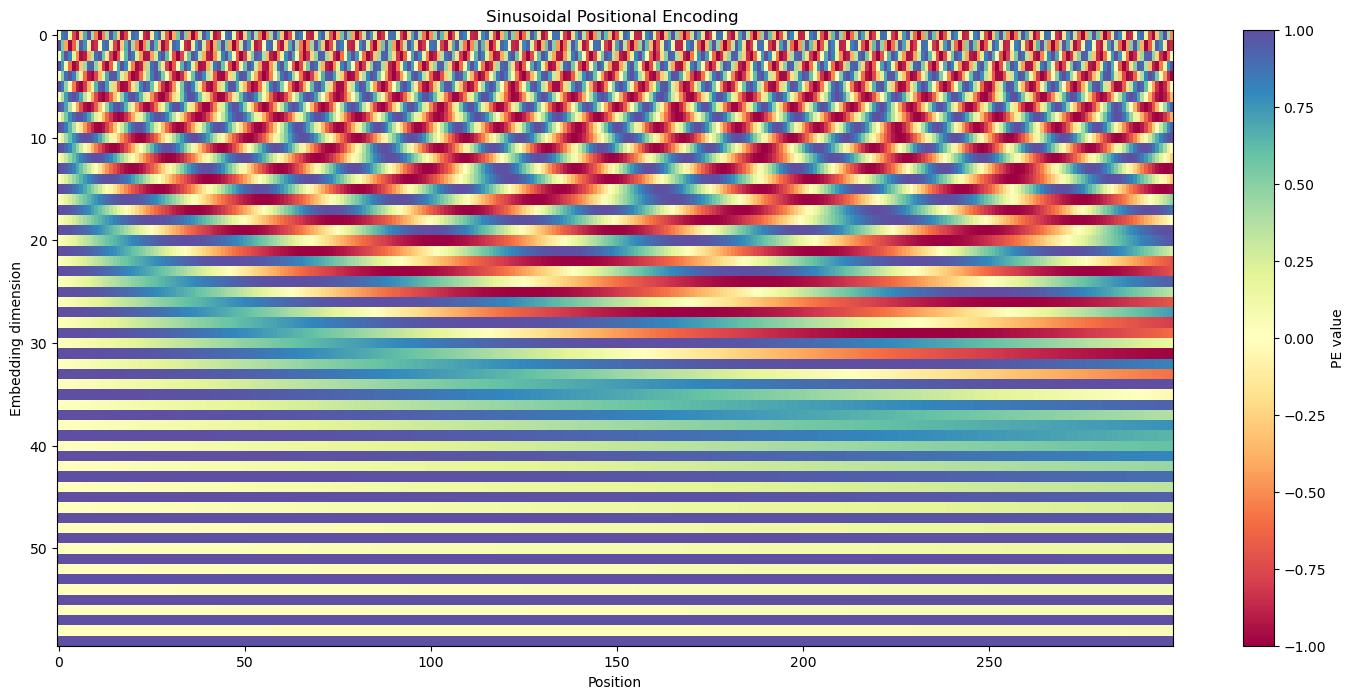

In [37]:
plot_pos()

## VIT Encoder Architecture

### Multi-head-attention

In [38]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embdim, num_heads):
        super().__init__()

        self.num_heads = num_heads
        self.head_dim = embdim // num_heads

        self.Wq = nn.Linear(embdim, embdim)
        self.Wk = nn.Linear(embdim, embdim)
        self.Wv = nn.Linear(embdim, embdim)

        self.out = nn.Linear(embdim, embdim)

    def forward(self, x):
        B, T, D = x.shape

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        # split heads
        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        # attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        weights = F.softmax(scores, dim=-1)

        out = torch.matmul(weights, V)

        # merge heads
        out = out.transpose(1, 2).contiguous().view(B, T, D)

        return self.out(out)

### Feed-Forward Network

In [39]:
class FeedForward(nn.Module):
    def __init__(self, embdim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embdim, hidden_dim),
            nn.GELU(),   # better than ReLU
            nn.Linear(hidden_dim, embdim)
        )

    def forward(self, x):
        return self.net(x)

### EncoderBlock

In [40]:
class EncoderBlock(nn.Module):
    def __init__(self, embdim, num_heads, ff_hidden_dim):
        super().__init__()

        self.norm1 = nn.LayerNorm(embdim)
        self.norm2 = nn.LayerNorm(embdim)

        self.mha = MultiHeadAttention(embdim, num_heads)
        self.ff = FeedForward(embdim, ff_hidden_dim)

    def forward(self, x):
        x = x + self.mha(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x

### ViTEncoder

In [41]:
class ViTEncoder(nn.Module):
    def __init__(self, depth, embdim, num_heads, ff_hidden_dim):
        super().__init__()

        self.layers = nn.ModuleList([
            EncoderBlock(embdim, num_heads, ff_hidden_dim)
            for _ in range(depth)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [42]:
x = torch.randn(2, 64, 768)

vit = ViTEncoder(depth=6, embdim=768, num_heads=12, ff_hidden_dim=3072)

out = vit(x)

print(out.shape)

torch.Size([2, 64, 768])


## DECODER Architecture

### MaskedMultiHeadAttention

In [43]:
class MaskedMultiHeadAttention(nn.Module):
    def __init__(self, embdim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embdim // num_heads

        self.Wq = nn.Linear(embdim, embdim)
        self.Wk = nn.Linear(embdim, embdim)
        self.Wv = nn.Linear(embdim, embdim)

        self.out = nn.Linear(embdim, embdim)

    def forward(self, x):
        B, T, D = x.shape

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # CAUSAL MASK
        mask = torch.tril(torch.ones(T, T, device=x.device)).bool()
        scores = scores.masked_fill(~mask, float('-inf'))

        weights = F.softmax(scores, dim=-1)
        out = torch.matmul(weights, V)

        out = out.transpose(1, 2).contiguous().view(B, T, D)

        return self.out(out)

### CrossAttention

In [44]:
class CrossAttention(nn.Module):
    def __init__(self, embdim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embdim // num_heads

        self.Wq = nn.Linear(embdim, embdim)
        self.Wk = nn.Linear(embdim, embdim)
        self.Wv = nn.Linear(embdim, embdim)

        self.out = nn.Linear(embdim, embdim)

    def forward(self, query, context):
        """
        query: (B, T, D) → text
        context: (B, N, D) → image
        """
        B, T, D = query.shape
        N = context.shape[1]

        Q = self.Wq(query)
        K = self.Wk(context)
        V = self.Wv(context)

        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        weights = F.softmax(scores, dim=-1)

        out = torch.matmul(weights, V)
        out = out.transpose(1, 2).contiguous().view(B, T, D)

        return self.out(out)

### DecoderBlock

In [45]:
class DecoderBlock(nn.Module):
    def __init__(self, embdim, num_heads, ff_hidden_dim):
        super().__init__()

        self.norm1 = nn.LayerNorm(embdim)
        self.norm2 = nn.LayerNorm(embdim)
        self.norm3 = nn.LayerNorm(embdim)

        self.self_attn = MaskedMultiHeadAttention(embdim, num_heads)
        self.cross_attn = CrossAttention(embdim, num_heads)
        self.ff = FeedForward(embdim, ff_hidden_dim)

    def forward(self, text_tokens, image_tokens):
        # 1. Masked Self Attention
        x = text_tokens + self.self_attn(self.norm1(text_tokens))

        # 2. Cross Attention (text → image)
        x = x + self.cross_attn(self.norm2(x), image_tokens)

        # 3. Feed Forward
        x = x + self.ff(self.norm3(x))

        return x

### Decoder

In [46]:
class Decoder(nn.Module):
    def __init__(self, depth, embdim, num_heads, ff_hidden_dim):
        super().__init__()

        self.layers = nn.ModuleList([
            DecoderBlock(embdim, num_heads, ff_hidden_dim)
            for _ in range(depth)
        ])

    def forward(self, text_tokens, image_tokens):
        for layer in self.layers:
            text_tokens = layer(text_tokens, image_tokens)
        return text_tokens

In [47]:
B = 2
N_img = 64
T_text = 127
D = 768

# dummy tokens
image_tokens = torch.randn(B, N_img, D)
text_tokens = torch.randn(B, T_text, D)

In [48]:
# create decoder
decoder = Decoder(
    depth=4,
    embdim=D,
    num_heads=12,
    ff_hidden_dim=3072
)

In [49]:
x = torch.randn(1, 10, 768)

mha = MaskedMultiHeadAttention(768, 12)

out = mha(x)

print("Masked attention output:", out.shape)

Masked attention output: torch.Size([1, 10, 768])


## Vocab Head

In [50]:
class VocabHead(nn.Module):
    def __init__(self, embdim, vocab_size):
        super().__init__()
        self.proj = nn.Linear(embdim, vocab_size)

    def forward(self, x):
        """
        x: (B, T, D)
        """
        return self.proj(x)   # (B, T, vocab_size)

In [51]:
B, T, D = 2, 127, 768
vocab_size = 100

x = torch.randn(B, T, D)

head = VocabHead(D, vocab_size)

out = head(x)

print("Output shape:", out.shape)

Output shape: torch.Size([2, 127, 100])


# TRANSFORMER MODEL

In [52]:
class OCRTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        embdim=768,
        img_depth=6,
        txt_depth=6,
        num_heads=12,
        ff_hidden_dim=3072,
        max_len=128
    ):
        super().__init__()

        #  IMAGE PATH
        self.patch_embed = PatchEmbedding(in_channels=3, d_model=embdim)
        self.img_pos = ImagePositionalEmbedding(num_patches=64, d_model=embdim)
        self.vit = ViTEncoder(img_depth, embdim, num_heads, ff_hidden_dim)

        #  TEXT PATH
        self.text_emb = TextPositionalEmbedding(vocab_size, embdim, max_len)

        #  DECODER
        self.decoder = Decoder(txt_depth, embdim, num_heads, ff_hidden_dim)

        #  OUTPUT
        self.vocab_head = VocabHead(embdim, vocab_size)

    def forward(self, image, text):
        """
        image: (B, 3, 64, 256)
        text:  (B, T)
        """

        # IMAGE
        img_tokens = self.patch_embed(image)     # (B, 64, 768)
        img_tokens = self.img_pos(img_tokens)    # (B, 64, 768)
        img_tokens = self.vit(img_tokens)        # (B, 64, 768)

        # TEXT
        text_tokens = self.text_emb(text)        # (B, T, 768)

        # DECODER
        decoded = self.decoder(text_tokens, img_tokens)  # (B, T, 768)

        # OUTPUT
        logits = self.vocab_head(decoded)        # (B, T, vocab_size)

        return logits

In [53]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [54]:
my_model=OCRTransformer(100).to(device)




OCRTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): GELU(approximate='none')
      (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): GELU(approximate='none')
      (4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): GELU(approximate='none')
      (6): Conv2d(256, 768, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
  )
  (img_pos): ImagePositionalEmbedding()
  (vit): ViTEncoder(
    (layers): ModuleList(
      (0-5): 6 x EncoderBlock(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mha): MultiHeadAttention(
          (Wq): Linear(in_features=768, out_features=768, bias=True)
          (Wk): Linear(in_features=768, out_features=768, bias=True)
          (Wv): Linear(in_features=768, out_features=768, bias=T

In [55]:
B = 2
image = torch.randn(B, 3, 64, 256)
text = torch.randint(0, 100, (B, 127))  # including PAD=0

model = OCRTransformer(vocab_size=100)

out = model(image, text)
print("image shape:",image.shape)
print("text shape:",text.shape)
print("Output shape:", out.shape)

image shape: torch.Size([2, 3, 64, 256])
text shape: torch.Size([2, 127])
Output shape: torch.Size([2, 127, 100])


In [56]:
out

tensor([[[-1.1906, -0.3589,  1.0651,  ...,  1.5273,  0.1812, -0.8629],
         [-1.7551,  0.2155,  2.1147,  ...,  0.4693,  0.7410,  0.0699],
         [ 0.6593,  1.2502,  0.5120,  ...,  1.5226,  1.1779, -0.5094],
         ...,
         [ 0.4686,  0.2476,  0.4448,  ..., -0.1317, -0.4267, -0.9496],
         [-0.9370, -0.3272, -1.3001,  ...,  0.7271,  0.2006,  0.2215],
         [ 0.2167,  0.2068, -1.1642,  ..., -0.8803,  0.8658, -1.0017]],

        [[-0.9384,  1.4193,  1.6814,  ...,  0.0114, -1.1373, -1.3841],
         [-0.2510,  1.3843,  0.2083,  ..., -0.0893,  1.1422, -1.5967],
         [ 0.2119, -0.1336, -0.5987,  ...,  1.0665,  1.2608, -1.0719],
         ...,
         [ 0.1776,  0.2234, -0.7989,  ...,  0.4958,  0.1376, -0.5266],
         [ 0.9834,  1.2094, -0.9883,  ...,  0.2140,  0.6735, -0.4163],
         [ 0.2102, -0.6171,  0.1661,  ...,  0.1057,  0.1392, -0.4613]]],
       grad_fn=<ViewBackward0>)

### recording parameters for MY-MODEL

In [57]:
for name, param in my_model.named_parameters():
    print(name, param.requires_grad)

patch_embed.proj.0.weight True
patch_embed.proj.0.bias True
patch_embed.proj.2.weight True
patch_embed.proj.2.bias True
patch_embed.proj.4.weight True
patch_embed.proj.4.bias True
patch_embed.proj.6.weight True
patch_embed.proj.6.bias True
img_pos.pos_embed True
vit.layers.0.norm1.weight True
vit.layers.0.norm1.bias True
vit.layers.0.norm2.weight True
vit.layers.0.norm2.bias True
vit.layers.0.mha.Wq.weight True
vit.layers.0.mha.Wq.bias True
vit.layers.0.mha.Wk.weight True
vit.layers.0.mha.Wk.bias True
vit.layers.0.mha.Wv.weight True
vit.layers.0.mha.Wv.bias True
vit.layers.0.mha.out.weight True
vit.layers.0.mha.out.bias True
vit.layers.0.ff.net.0.weight True
vit.layers.0.ff.net.0.bias True
vit.layers.0.ff.net.2.weight True
vit.layers.0.ff.net.2.bias True
vit.layers.1.norm1.weight True
vit.layers.1.norm1.bias True
vit.layers.1.norm2.weight True
vit.layers.1.norm2.bias True
vit.layers.1.mha.Wq.weight True
vit.layers.1.mha.Wq.bias True
vit.layers.1.mha.Wk.weight True
vit.layers.1.mha.Wk.b

In [58]:
total_params = sum(p.numel() for p in my_model.parameters())
print(total_params)

101581796


In [59]:
trainable_params = sum(p.numel() for p in my_model.parameters() if p.requires_grad)
print(trainable_params)

101581796


In [60]:
num_param_tensors = len(list(my_model.named_parameters()))
print(num_param_tensors)

264


In [61]:
all_trainable = all(p.requires_grad for p in my_model.parameters())
print("All parameters trainable:", all_trainable)

All parameters trainable: True


### Accuracy function

In [62]:
def token_accuracy(logits, targets, pad_idx=0):
    """
    logits: (B, T, vocab)
    targets: (B, T)
    """
    preds = logits.argmax(dim=-1)  # (B, T)

    mask = targets != pad_idx

    correct = (preds == targets) & mask

    acc = correct.sum().float() / mask.sum().float()

    return acc.item()

### Train function

In [63]:
def train_model(
    model,
    dataloader,
    optimizer,
    loss_fn,
    device="cuda",
    epochs=5,
    vocab_size=100
):
    model.to(device)

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        total_acc = 0

        print(f"\nEpoch [{epoch+1}/{epochs}]")

        for batch_idx, batch in enumerate(dataloader):

            images = batch["image"].to(device)      # (B, 3, 64, 256)
            texts = batch["labels"].to(device)        # (B, T)

            #  SHIFT (teacher forcing)
            input_text = texts[:, :-1]
            target_text = texts[:, 1:]

            # forward
            logits = model(images, input_text)      # (B, T-1, vocab)

            # reshape for loss
            logits_flat = logits.reshape(-1, vocab_size)
            targets_flat = target_text.reshape(-1)

            loss = loss_fn(logits_flat, targets_flat)

            # backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # accuracy
            acc = token_accuracy(logits, target_text)

            total_loss += loss.item()
            total_acc += acc

            if batch_idx % 28 == 0:
                #  PRINT EVERY BATCH
                print(
                    f"Batch [{batch_idx+1}/{len(dataloader)}] "
                    f"Loss: {loss.item():.4f} "
                    f"Acc: {acc:.4f}"
                )

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)

        print(f"Epoch Summary → Loss: {avg_loss:.4f}, Acc: {avg_acc:.4f}")

In [64]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vocab_size = 100

model = OCRTransformer(vocab_size=vocab_size)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

loss_fn = torch.nn.CrossEntropyLoss(ignore_index=0)


## Train

In [65]:
%%time
train_model(
    model=model,
    dataloader=train_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=1,
    vocab_size=vocab_size
)


Epoch [1/1]
Batch [1/4204] Loss: 4.9167 Acc: 0.0085
Batch [29/4204] Loss: 3.5428 Acc: 0.1389
Batch [57/4204] Loss: 2.6923 Acc: 0.2475
Batch [85/4204] Loss: 2.7529 Acc: 0.1803
Batch [113/4204] Loss: 3.2493 Acc: 0.1584
Batch [141/4204] Loss: 2.1107 Acc: 0.4321
Batch [169/4204] Loss: 2.4153 Acc: 0.3185
Batch [197/4204] Loss: 2.1125 Acc: 0.3864
Batch [225/4204] Loss: 2.8581 Acc: 0.2553
Batch [253/4204] Loss: 2.3293 Acc: 0.3375
Batch [281/4204] Loss: 2.8507 Acc: 0.3134
Batch [309/4204] Loss: 2.7275 Acc: 0.2578
Batch [337/4204] Loss: 2.0873 Acc: 0.3934
Batch [365/4204] Loss: 2.9559 Acc: 0.2966
Batch [393/4204] Loss: 1.7456 Acc: 0.5641
Batch [421/4204] Loss: 2.4984 Acc: 0.3053
Batch [449/4204] Loss: 2.0651 Acc: 0.4259
Batch [477/4204] Loss: 1.6738 Acc: 0.5669
Batch [505/4204] Loss: 1.3360 Acc: 0.5775
Batch [533/4204] Loss: 1.7151 Acc: 0.5315
Batch [561/4204] Loss: 1.6550 Acc: 0.5714
Batch [589/4204] Loss: 1.6839 Acc: 0.5109
Batch [617/4204] Loss: 1.9094 Acc: 0.5195
Batch [645/4204] Loss: 1.4

# save models

In [66]:
from pathlib import Path
root=Path('models')
root.mkdir(exist_ok=True)
path1= root / "OCRTransformer.pth"

In [67]:
torch.save(model,path1)